In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
matplotlib.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

## 数据加载与大类映射
请根据实际路径修改数据文件路径。

In [6]:
# 路径请根据实际情况修改
code_csv = 'F:/TensorFlow/xinjiang/traindata20250626_2.csv'
mapping_csv = 'F:/TensorFlow/xinjiang/traindata20250626_2_class_mapping.csv'

df = pd.read_csv(code_csv, encoding='utf_8_sig')
mapping_df = pd.read_csv(mapping_csv, encoding='utf_8_sig')

# 假设 mapping_df 有 'ClassName', 'num', 'Veg_Formation' 三列，无植被型数字编码
# 先为 mapping_df 添加植被型数字编码
mapping_df['Veg_Formation_num'] = mapping_df['Veg_Formation'].astype('category').cat.codes
print('植被型名称与编码映射：')
print(dict(zip(mapping_df['Veg_Formation'], mapping_df['Veg_Formation_num'])))
# 先为原始数据添加植被型和植被型编码
class2veg = dict(zip(mapping_df['ClassName'], mapping_df['Veg_Formation']))
class2veg_num = dict(zip(mapping_df['ClassName'], mapping_df['Veg_Formation_num']))
df['Veg_Formation'] = df['ClassName'].map(class2veg)
df['Veg_Formation_num'] = df['ClassName'].map(class2veg_num)
# 检查映射
assert not df['Veg_Formation_num'].isnull().any(), "有ClassName未能映射到植被型编码"

植被型名称与编码映射：
{'丛生草类草原': 0, '半灌木与草本荒漠': 4, '农业植被': 2, '裸地': 8, '半乔木与灌木荒漠': 3, '根茎草类草甸': 7, '半灌木草原': 5, '杂类草草原': 6, '丛生草类草甸': 1}


## 大类分类模型训练与评估

In [7]:
def build_model(input_dim, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_dim=input_dim, kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

def get_xy(df, label_col, drop_cols):
    feature_cols = [col for col in df.columns if col not in drop_cols]
    x = df[feature_cols].values
    y = df[label_col].values
    return x, y

def train_eval_model(x_train, y_train, x_test, y_test, num_classes, verbose=0, model_name=None):
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
    model = build_model(x_train.shape[1], num_classes)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=8, verbose=0)
    history = model.fit(x_train, y_train_cat, epochs=200, batch_size=64, verbose=verbose, callbacks=[reduce_lr, early_stopping])
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    epochs_trained = len(history.history['loss'])
    final_acc = history.history[acc_key][-1]
    final_loss = history.history['loss'][-1]
    print(f"训练轮数: {epochs_trained}, 最终训练精度: {final_acc:.4f}, 最终训练损失: {final_loss:.4f}")
    # 简化标题，仅保留中文名
    simple_name = None
    if model_name:
        # 取最后一个汉字及其后内容作为主名
        import re
        m = re.search(r'([\u4e00-\u9fa5]+.*)$', model_name)
        simple_name = m.group(1) if m else model_name
    # 并列绘制loss和acc曲线
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history.history['loss'], color =  'y')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f"{simple_name if simple_name else ''}Loss", fontweight='bold')
    axes[1].plot(history.history[acc_key], color =  'g')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f"{simple_name if simple_name else ''}Accuracy", fontweight='bold')
    plt.tight_layout()
    plt.show()
    y_pred = model.predict(x_test).argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    return [acc, precision, recall, f1], per_class_acc, model


训练轮数: 200, 最终训练精度: 0.7905, 最终训练损失: 0.7605


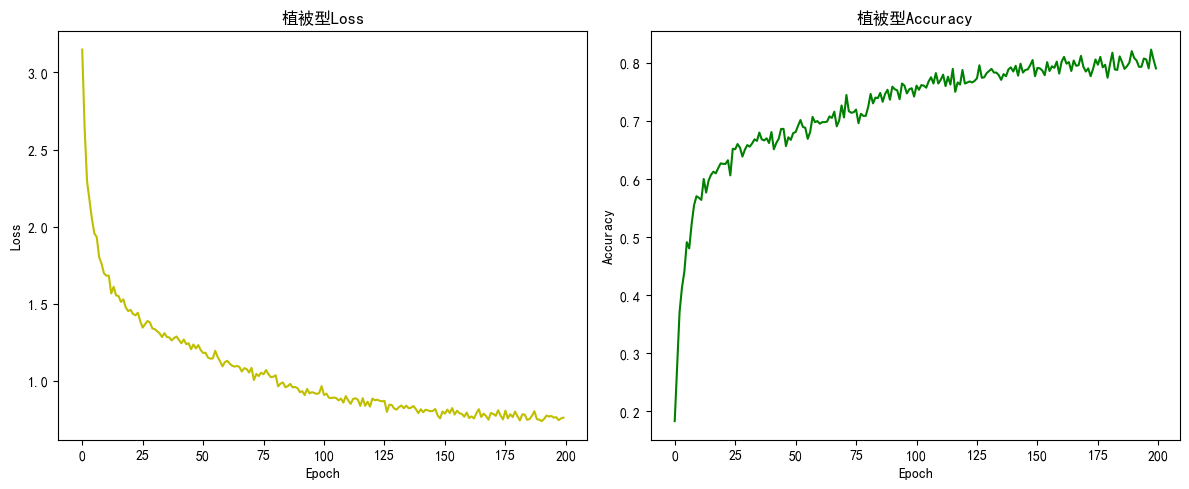

训练大类 0 - 丛生草类草原 下的小类分类器 (1/9) ...
训练轮数: 167, 最终训练精度: 0.9010, 最终训练损失: 0.6818
训练轮数: 167, 最终训练精度: 0.9010, 最终训练损失: 0.6818


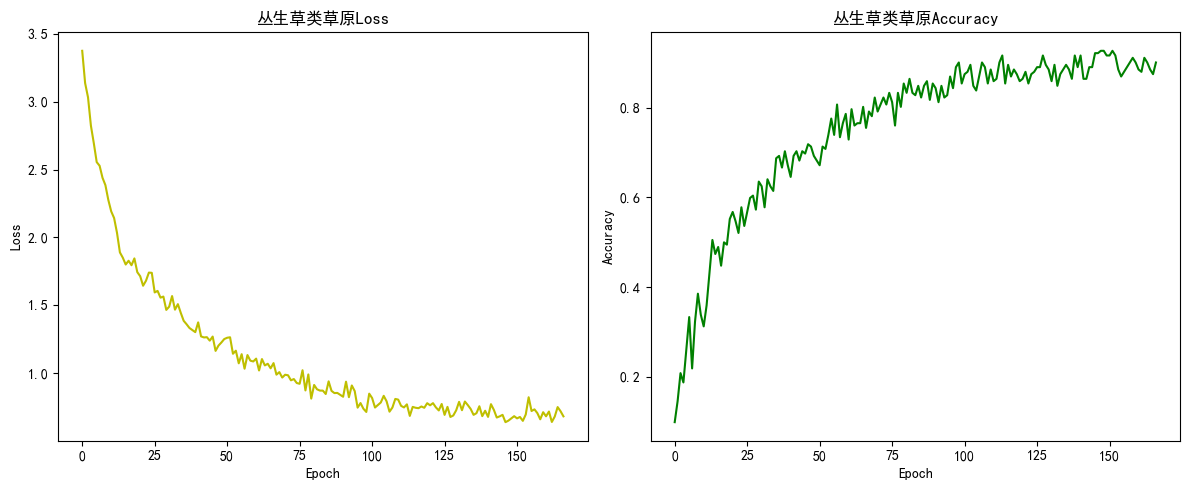

训练大类 1 - 丛生草类草甸 下的小类分类器 (2/9) ...
训练轮数: 60, 最终训练精度: 0.7647, 最终训练损失: 0.9719
训练轮数: 60, 最终训练精度: 0.7647, 最终训练损失: 0.9719


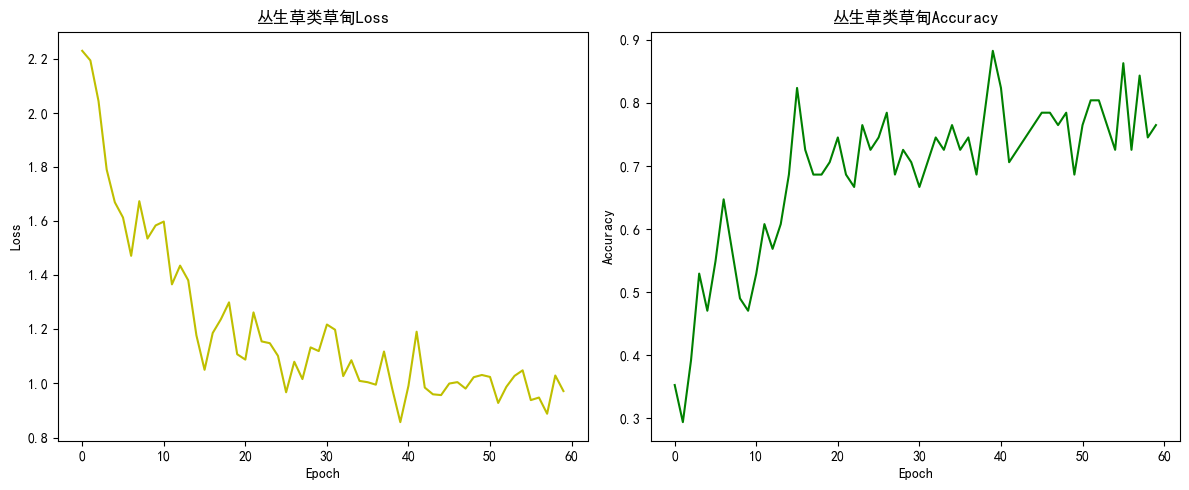

训练大类 2 - 农业植被 下的小类分类器 (3/9) ...
训练大类 3 - 半乔木与灌木荒漠 下的小类分类器 (4/9) ...
训练轮数: 164, 最终训练精度: 0.9576, 最终训练损失: 0.5298
训练轮数: 164, 最终训练精度: 0.9576, 最终训练损失: 0.5298


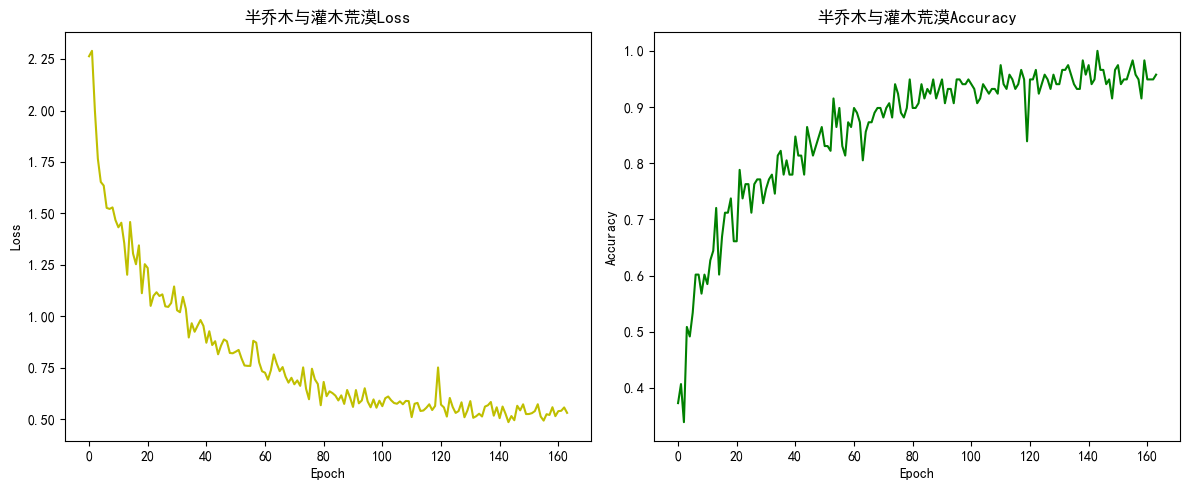

训练大类 4 - 半灌木与草本荒漠 下的小类分类器 (5/9) ...
训练轮数: 166, 最终训练精度: 0.7176, 最终训练损失: 1.2402
训练轮数: 166, 最终训练精度: 0.7176, 最终训练损失: 1.2402


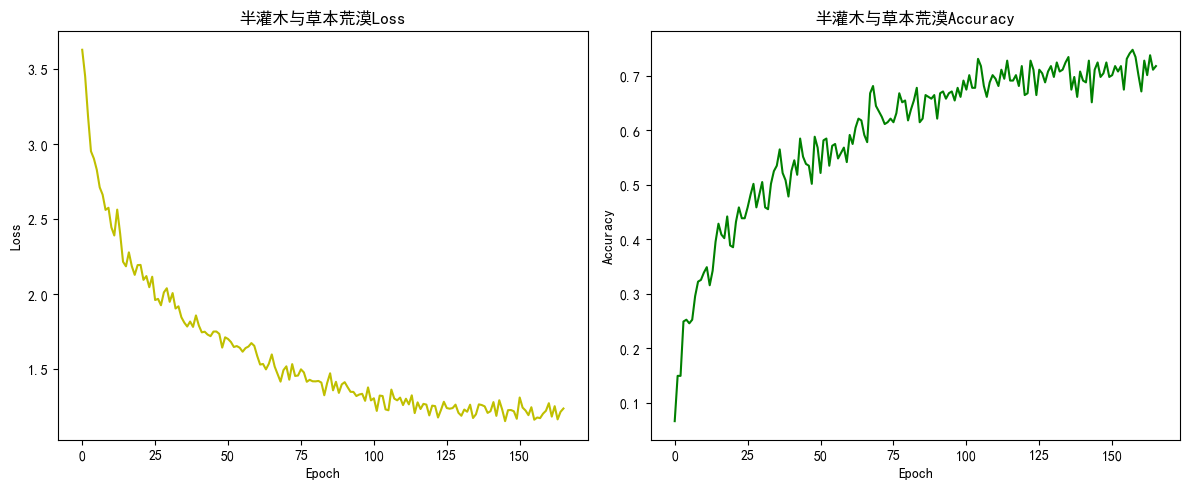

训练大类 5 - 半灌木草原 下的小类分类器 (6/9) ...
训练大类 6 - 杂类草草原 下的小类分类器 (7/9) ...
训练大类 7 - 根茎草类草甸 下的小类分类器 (8/9) ...
训练轮数: 101, 最终训练精度: 0.9070, 最终训练损失: 0.5720
训练轮数: 101, 最终训练精度: 0.9070, 最终训练损失: 0.5720


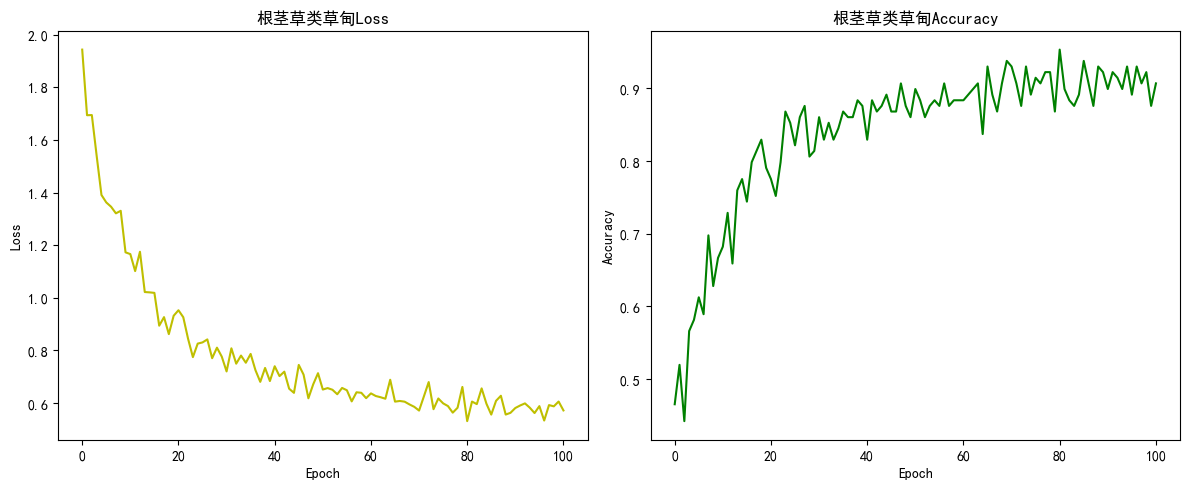

训练大类 8 - 裸地 下的小类分类器 (9/9) ...
植被型（大类）验证集评估:
Accuracy: 0.6953, Precision: 0.5081, Recall: 0.5275, F1 Score: 0.5151
所有群系整体评估:
Accuracy: 0.6148, Precision: 0.6116, Recall: 0.5659, F1 Score: 0.5667


,植被型编码,植被型名称,群系编码,群系名称,群系精度
0,0,丛生草类草原,0,针茅属草原,0.500000
1,0,丛生草类草原,1,紫花针茅草原,0.800000
2,0,丛生草类草原,2,早熟禾属草甸,0.500000
3,0,丛生草类草原,3,新疆银穗草、穗状寒生羊茅荒漠草原,0.500000
4,0,丛生草类草原,4,针茅属高寒草原,0.166667
5,0,丛生草类草原,5,针茅属荒漠草原,0.600000
6,0,丛生草类草原,6,新疆银穗草草原,0.000000
7,1,丛生草类草甸,0,嵩草属草甸,0.000000
8,1,丛生草类草甸,1,线叶嵩草草甸,0.000000
9,1,丛生草类草甸,2,鸭茅草甸,1.000000


In [8]:
# 划分训练集和测试集
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_ratio = 0.2
idx = np.random.permutation(len(df))
split_idx = int(len(df) * (1 - test_ratio))
train_df = df.iloc[idx[:split_idx]]
test_df = df.iloc[idx[split_idx:]]

# 大类分类（只用于预测，不评估）
drop_cols = ['className', 'ClassName', 'num', 'Veg_Formation', 'Veg_Formation_num']
x_train, y_train = get_xy(train_df, 'Veg_Formation_num', drop_cols)
x_test, y_test = get_xy(test_df, 'Veg_Formation_num', drop_cols)
num_veg_classes = df['Veg_Formation_num'].nunique()
veg_label_map = dict(zip(mapping_df['Veg_Formation_num'], mapping_df['Veg_Formation']))

_, _, veg_model = train_eval_model(x_train, y_train, x_test, y_test, num_veg_classes, model_name='植被型')

# 用大类模型预测测试集大类标签
test_df = test_df.copy()
test_df['Veg_Formation_num_pred'] = veg_model.predict(x_test).argmax(axis=1)

# 在预测大类的基础上对小类进行分类和评估
all_true = []
all_pred = []
sub_acc_rows = []
veg_nums = sorted(df['Veg_Formation_num'].unique())
for idx, veg_num in enumerate(veg_nums):
    veg_name = veg_label_map.get(veg_num, str(veg_num))
    print(f"训练大类 {veg_num} - {veg_name} 下的小类分类器 ({idx+1}/{len(veg_nums)}) ...")
    sub_test = test_df[test_df['Veg_Formation_num_pred'] == veg_num]
    sub_train = train_df[train_df['Veg_Formation_num'] == veg_num]
    if len(sub_train) < 2 or len(sub_test) < 1:
        continue
    sub_class_names = sub_train['ClassName'].unique()
    class_name2num = {name: i for i, name in enumerate(sub_class_names)}
    sub_train = sub_train.copy()
    sub_test = sub_test.copy()
    sub_train['sub_num'] = sub_train['ClassName'].map(class_name2num)
    sub_test['sub_num'] = sub_test['ClassName'].map(class_name2num)
    sub_test = sub_test[~sub_test['sub_num'].isnull()]
    if len(class_name2num) < 2 or len(sub_test) < 1:
        continue
    # 只保留两边都存在的特征列
    feature_cols = [col for col in sub_train.columns if col not in drop_cols + ['sub_num']]
    feature_cols = [col for col in feature_cols if col in sub_test.columns]
    x_train_sub = sub_train[feature_cols].values
    y_train_sub = sub_train['sub_num'].values
    x_test_sub = sub_test[feature_cols].values
    y_test_sub = sub_test['sub_num'].values
    num_sub_classes = len(class_name2num)
    _, _, sub_model = train_eval_model(x_train_sub, y_train_sub, x_test_sub, y_test_sub, num_sub_classes, model_name=f'{veg_name}')
    y_pred_sub = sub_model.predict(x_test_sub).argmax(axis=1)
    all_true.extend(y_test_sub)
    all_pred.extend(y_pred_sub)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_sub, y_pred_sub, labels=np.arange(num_sub_classes))
    # 消除除0除法和无效操作的警告
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.where(cm.sum(axis=1) == 0, np.nan, cm.diagonal() / cm.sum(axis=1))
    for cname, idx2 in class_name2num.items():
        sub_acc_rows.append({
            '植被型编码': veg_num,
            '植被型名称': veg_name,
            '群系编码': idx2,
            '群系名称': cname,
            '群系精度': per_class_acc[idx2] if idx2 < len(per_class_acc) else None
        })

# 大类验证集评估
veg_pred = veg_model.predict(x_test).argmax(axis=1)
veg_acc = accuracy_score(y_test, veg_pred)
veg_precision = precision_score(y_test, veg_pred, average='macro', zero_division=0)
veg_recall = recall_score(y_test, veg_pred, average='macro', zero_division=0)
veg_f1 = f1_score(y_test, veg_pred, average='macro', zero_division=0)
print('植被型（大类）验证集评估:')
print(f'Accuracy: {veg_acc:.4f}, Precision: {veg_precision:.4f}, Recall: {veg_recall:.4f}, F1 Score: {veg_f1:.4f}')

# 所有小类整体四项指标
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
global_acc = accuracy_score(all_true, all_pred)
global_precision = precision_score(all_true, all_pred, average='macro', zero_division=0)
global_recall = recall_score(all_true, all_pred, average='macro', zero_division=0)
global_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
print('所有群系整体评估:')
print(f'Accuracy: {global_acc:.4f}, Precision: {global_precision:.4f}, Recall: {global_recall:.4f}, F1 Score: {global_f1:.4f}')

# 各小类精度表
df_sub_acc = pd.DataFrame(sub_acc_rows, columns=['植被型编码', '植被型名称', '群系编码', '群系名称', '群系精度'])
display(df_sub_acc)